# Stop Re-running: Efficient Numerical Integration via Solver Log and Resumption

Original QMCPy demo: [`QMCPy/demos/demo_resume_data/Iteration_Log_Tolerance_Demo.ipynb`](../../../QMCPy/demos/demo_resume_data/Iteration_Log_Tolerance_Demo.ipynb)

This Julia version compares the same two workflows: solving each tolerance from scratch versus progressively resuming from the previous tolerance.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/demo_resume_data/Iteration_Log_Tolerance_Demo.ipynb)

In [1]:
using QMC
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


In [2]:
tols = [1e-3 / 2.0^k for k in 0:5]

function make_solver(abs_tol; seed=7)
    dd = Lattice(3; seed=seed)
    f = Genz(Uniform(dd); kind=:oscillatory, a=ones(3), u=0.5 .* ones(3))
    return CubQMCLatticeG(f; abs_tol=abs_tol, trace_iterations=true)
end

function run_fresh_curve()
    rows = NamedTuple[]
    for eps in tols
        r = integrate(make_solver(eps))
        push!(rows, (abs_tol=eps, n_total=r.data[:n_total], elapsed=r.data[:time_integrate], solution=r.solution))
    end
    return rows
end

function run_resume_curve()
    rows = NamedTuple[]
    resume_state = nothing
    cumulative = 0.0
    for eps in tols
        r = isnothing(resume_state) ? integrate(make_solver(eps)) : integrate(make_solver(eps); resume=resume_state)
        cumulative += r.data[:time_integrate]
        stop_row = iterations(r.data[:iteration_log])[end]
        push!(rows, (abs_tol=eps, n_total=r.data[:n_total], elapsed=cumulative, solution=r.solution, stop_row=stop_row))
        resume_state = r.data
    end
    return rows
end

fresh_rows = run_fresh_curve()
resume_rows = run_resume_curve()


6-element Vector{NamedTuple}:
 (abs_tol = 0.001, n_total = 16384, elapsed = 0.0002541542053222656, solution = -0.062223849929872836, stop_row = (iter = 1, n = 16384, solution = -0.062223849929872836, error_bound = 0.0003668706465500193, tol = 0.001, elapsed = 0.0002541542053222656))
 (abs_tol = 0.0005, n_total = 32768, elapsed = 0.004775285720825195, solution = -0.06236903057758148, stop_row = (iter = 1, n = 32768, solution = -0.06236903057758148, error_bound = 0.0001911878328093158, tol = 0.0005, elapsed = 0.0004639625549316406))
 (abs_tol = 0.00025, n_total = 65536, elapsed = 0.010248422622680664, solution = -0.06240973714001785, stop_row = (iter = 1, n = 65536, solution = -0.06240973714001785, error_bound = 8.784764317289537e-5, tol = 0.00025, elapsed = 0.000949859619140625))
 (abs_tol = 0.000125, n_total = 131072, elapsed = 0.018175601959228516, solution = -0.06238140666549654, stop_row = (iter = 1, n = 131072, solution = -0.06238140666549654, error_bound = 6.0376488529861935e-5, t

## Approach 2. Iteration Log with Resume Approach

The solver is executed by first running it at the loosest tolerance and then resuming at progressively tighter tolerances. Because each resumption starts from the previous state, the cumulative time and sample count grow only as needed.


In [3]:
println("Fresh solves:")
foreach(println, fresh_rows)
println("
Resume solves:")
foreach(println, resume_rows)

fresh_total_samples = sum(row.n_total for row in fresh_rows)
resume_total_samples = resume_rows[end].n_total
@printf("
Total samples when re-running from scratch: %d
", fresh_total_samples)
@printf("Samples after progressive resumption: %d
", resume_total_samples)
@printf("Sample reuse factor: %.2f×
", fresh_total_samples / resume_total_samples)


Fresh solves:
(abs_tol

 = 0.001, n_total = 16384, elapsed = 0.0033969879150390625, solution = -0.062223849929872836)
(abs_tol = 0.0005, n_total = 16384, elapsed = 0.00037097930908203125, solution = -0.062223849929872836)
(abs_tol = 0.00025, n_total = 32768, elapsed = 0.012166976928710938, solution = -0.06222641556727295)
(abs_tol = 0.000125, n_total = 65536, elapsed = 0.0020151138305664062, solution = -0.062378451918581844)
(abs_tol = 6.25e-5, n_total = 262144, elapsed = 0.061860084533691406, solution = -0.06239521586005563)
(abs_tol = 3.125e-5, n_total = 524288, elapsed = 0.07049393653869629, solution = -0.06235929578452748)

Resume solves:
(abs_tol = 0.001, n_total = 16384, elapsed = 0.0002541542053222656, solution = -0.062223849929872836, stop_row = (

iter = 1, n = 16384, solution = -0.062223849929872836, error_bound = 0.0003668706465500193, tol = 0.001, elapsed = 0.0002541542053222656))
(abs_tol = 0.0005, n_total = 32768, elapsed = 0.004775285720825195, solution = -0.06236903057758148, stop_row = (iter = 1, n = 32768, solution = -0.06236903057758148, error_bound = 0.0001911878328093158, tol = 0.0005, elapsed = 0.0004639625549316406))
(abs_tol = 0.00025, n_total = 65536, elapsed = 0.010248422622680664, solution = -0.06240973714001785, stop_row = (iter = 1, n = 65536, solution = -0.06240973714001785, error_bound = 8.784764317289537e-5, tol = 0.00025, elapsed = 0.000949859619140625))
(abs_tol = 0.000125, n_total = 131072, elapsed = 0.018175601959228516, solution = -0.06238140666549654, stop_row = (iter = 1, n = 131072, solution = -0.06238140666549654, error_bound = 6.0376488529861935e-5, tol = 0.000125, elapsed = 0.0024530887603759766))
(abs_tol = 6.25e-5, n_total = 262144, elapsed = 0.03447079658508301, solution = -0.0623484287904035

Sample reuse factor: 1.75×


Below, we inspect the stored stop rows from the iteration log. These are the Julia counterpart to the reviewable iteration log used in the QMCPy notebook.


In [4]:
for row in resume_rows
    println(row.stop_row)
end

@assert resume_total_samples < fresh_total_samples
@assert all(abs(f.solution - r.solution) ≤ f.abs_tol for (f, r) in zip(fresh_rows, resume_rows))


(iter = 1, n = 16384, solution = -0.062223849929872836, error_bound = 0.0003668706465500193, tol = 0.001, elapsed = 0.0002541542053222656)
(iter = 1, n = 32768, solution = -0.06236903057758148, error_bound = 0.0001911878328093158, tol = 0.0005, elapsed = 0.0004639625549316406)
(iter = 1, n = 65536, solution = -0.06240973714001785, error_bound = 8.784764317289537e-5, tol = 0.00025, elapsed = 0.000949859619140625)
(iter = 1, n = 131072, solution = -0.06238140666549654, error_bound = 6.0376488529861935e-5, tol = 0.000125, elapsed = 0.0024530887603759766)
(iter = 1, n = 262144, solution = -0.062348428790403546, error_bound = 2.4466699483028488e-5, tol = 6.25e-5, elapsed = 0.008365869522094727)
(iter = 1, n = 524288, solution = -0.06235885773195256, error_bound = 1.1271645489812593e-5, tol = 3.125e-5, elapsed = 0.013160943984985352)


## Efficiency Visualization


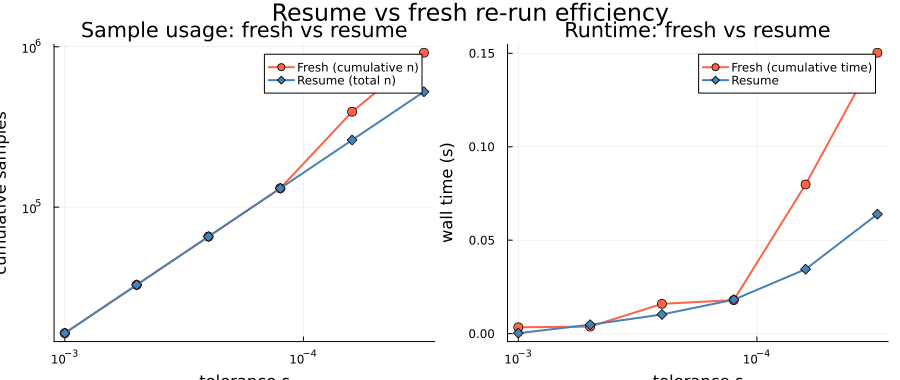

In [5]:
if HAVE_PLOTS
    # Plot: samples used vs tolerance  (fresh re-run vs resume)
    tols_plot    = [row.abs_tol for row in fresh_rows]
    n_fresh      = [row.n_total for row in fresh_rows]
    n_resume     = [row.n_total for row in resume_rows]
    t_fresh      = [row.elapsed for row in fresh_rows]
    t_resume     = [row.elapsed for row in resume_rows]

    p1 = plot(tols_plot, cumsum(n_fresh);
        xscale=:log10, yscale=:log10, xflip=true,
        marker=:circle, lw=2, ms=5, color=:tomato,
        label="Fresh (cumulative n)",
        xlabel="tolerance ε", ylabel="cumulative samples",
        title="Sample usage: fresh vs resume")
    plot!(tols_plot, n_resume;
        marker=:diamond, lw=2, ms=5, color=:steelblue, label="Resume (total n)")

    p2 = plot(tols_plot, cumsum(t_fresh);
        xscale=:log10, xflip=true,
        marker=:circle, lw=2, ms=5, color=:tomato,
        label="Fresh (cumulative time)",
        xlabel="tolerance ε", ylabel="wall time (s)",
        title="Runtime: fresh vs resume")
    plot!(tols_plot, t_resume;
        marker=:diamond, lw=2, ms=5, color=:steelblue, label="Resume")

    display(plot(p1, p2; layout=(1, 2), size=(900, 380),
        plot_title="Resume vs fresh re-run efficiency"))
end
